# INHALEX — Generación y validación de tres datasets sintéticos

Esta libreta genera y audita tres datasets independientes: recomendación de aromas, predicción de demanda y segmentación de clientes. Todos los registros son ficticios, reproducibles y están etiquetados como sintéticos. No representan testimonios ni comportamiento de clientes reales.

## 1. Entorno reproducible

La semilla, el periodo, los 300 clientes y los 1,800 pedidos se controlan desde `ml/config/synthetic-config.json`. La libreta no se conecta a MongoDB.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

def locate_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'ml' / 'config' / 'synthetic-config.json').exists():
            return candidate
    raise FileNotFoundError('Ejecuta la libreta dentro del repositorio Proyecto-INHALEX')

REPO_ROOT = locate_repo_root()
EXPORT_DIR = REPO_ROOT / 'ml' / 'exports'
CONFIG = json.loads((REPO_ROOT / 'ml' / 'config' / 'synthetic-config.json').read_text(encoding='utf-8'))
SEED = int(CONFIG['random_seed'])
sns.set_theme(style='whitegrid', palette='crest')
pd.set_option('display.max_columns', 80)
CONFIG

{'generation_run_id': 'inhalex-synthetic-v1',
 'random_seed': 20260717,
 'start_date': '2025-01-01',
 'end_date': '2026-06-30',
 'customer_count': 300,
 'order_count': 1800,
 'target_horizon_months': 1,
 'timezone': 'America/Mexico_City',
 'currency': 'MXN',
 'base_unit_price': 60,
 'output_directory': 'ml/exports'}

## 2. Generación determinista

El generador se ejecuta desde la libreta para que el procedimiento sea demostrable. Cambiar `REGENERATE` a `False` permite revisar archivos ya existentes.

In [2]:
REGENERATE = True
if REGENERATE:
    subprocess.run(
        [sys.executable, str(REPO_ROOT / 'ml' / 'src' / 'generate_synthetic_datasets.py')],
        cwd=REPO_ROOT,
        check=True,
    )

subprocess.run(
    [sys.executable, str(REPO_ROOT / 'ml' / 'src' / 'validate_synthetic_datasets.py')],
    cwd=REPO_ROOT,
    check=True,
)

CompletedProcess(args=['C:\\Users\\David\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe', 'C:\\Users\\David\\Documents\\Proyecto-INHALEX\\ml\\src\\validate_synthetic_datasets.py'], returncode=0)

In [3]:
recommendation = pd.read_csv(
    EXPORT_DIR / 'dataset_recomendacion_aromas.csv',
    encoding='utf-8-sig',
    parse_dates=['occurred_at'],
)
demand = pd.read_csv(
    EXPORT_DIR / 'dataset_prediccion_demanda.csv',
    encoding='utf-8-sig',
    parse_dates=['fecha_corte', 'mes_objetivo'],
)
segmentation = pd.read_csv(
    EXPORT_DIR / 'dataset_segmentacion_clientes.csv',
    encoding='utf-8-sig',
    parse_dates=['snapshot_date'],
)

pd.DataFrame({
    'dataset': ['recomendación', 'demanda', 'segmentación'],
    'filas': [len(recommendation), len(demand), len(segmentation)],
    'columnas': [recommendation.shape[1], demand.shape[1], segmentation.shape[1]],
    'completitud_pct': [
        recommendation.notna().mean().mean() * 100,
        demand.notna().mean().mean() * 100,
        segmentation.notna().mean().mean() * 100,
    ],
}).round(2)

,dataset,filas,columnas,completitud_pct
0,recomendación,22274,21,74.15
1,demanda,288,17,94.40
2,segmentación,300,28,98.74


## 3. Dataset de recomendación

Una fila representa una interacción cliente-producto. Los eventos conservan tiempo para poder hacer una división cronológica. Solo las compras y reseñas contienen `order_id`; los eventos anteriores no conocen el pedido futuro.

,valor
interacciones,22274.00
clientes,300.00
productos,16.00
compras_completadas,1674.00
reseñas,482.00
rating_promedio,4.24
canastas_multiproducto_pct,51.43


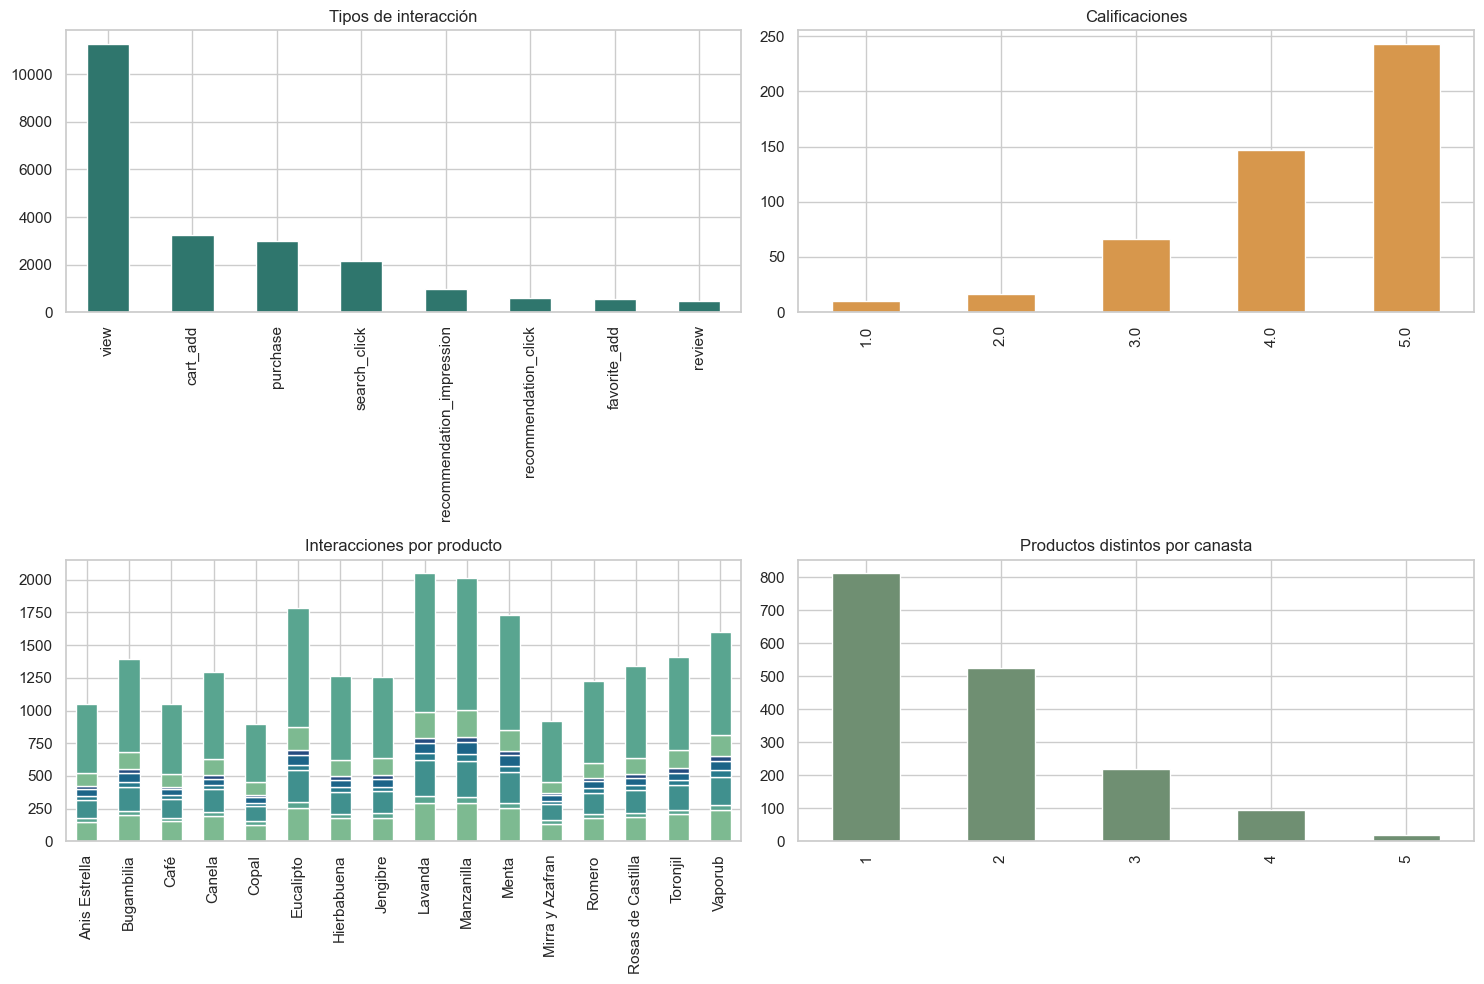

In [4]:
reviews = recommendation.query("event_type == 'review'").copy()
purchases = recommendation.query("event_type == 'purchase'").copy()
basket_sizes = purchases.groupby('order_id')['product_id'].nunique()

recommendation_summary = pd.Series({
    'interacciones': len(recommendation),
    'clientes': recommendation['customer_key'].nunique(),
    'productos': recommendation['product_id'].nunique(),
    'compras_completadas': purchases['order_id'].nunique(),
    'reseñas': len(reviews),
    'rating_promedio': reviews['review_rating'].mean(),
    'canastas_multiproducto_pct': basket_sizes.ge(2).mean() * 100,
})
display(recommendation_summary.round(2).to_frame('valor'))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
recommendation['event_type'].value_counts().plot.bar(ax=axes[0, 0], color='#2f766d', title='Tipos de interacción')
reviews['review_rating'].value_counts().sort_index().plot.bar(ax=axes[0, 1], color='#d7974c', title='Calificaciones')
pd.crosstab(recommendation['product_name'], recommendation['event_type']).plot(kind='bar', stacked=True, ax=axes[1, 0], legend=False, title='Interacciones por producto')
basket_sizes.value_counts().sort_index().plot.bar(ax=axes[1, 1], color='#6f8f72', title='Productos distintos por canasta')
for axis in axes.flat:
    axis.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. Dataset de demanda

La matriz contiene una fila por producto y mes objetivo: 16 productos × 18 meses = 288 filas, incluyendo meses con cero solicitudes. La variable Y es `Y_unidades_solicitadas_mes`; los tres rezagos, el precio, los pedidos y las reseñas solo usan información disponible antes de comenzar el mes objetivo.

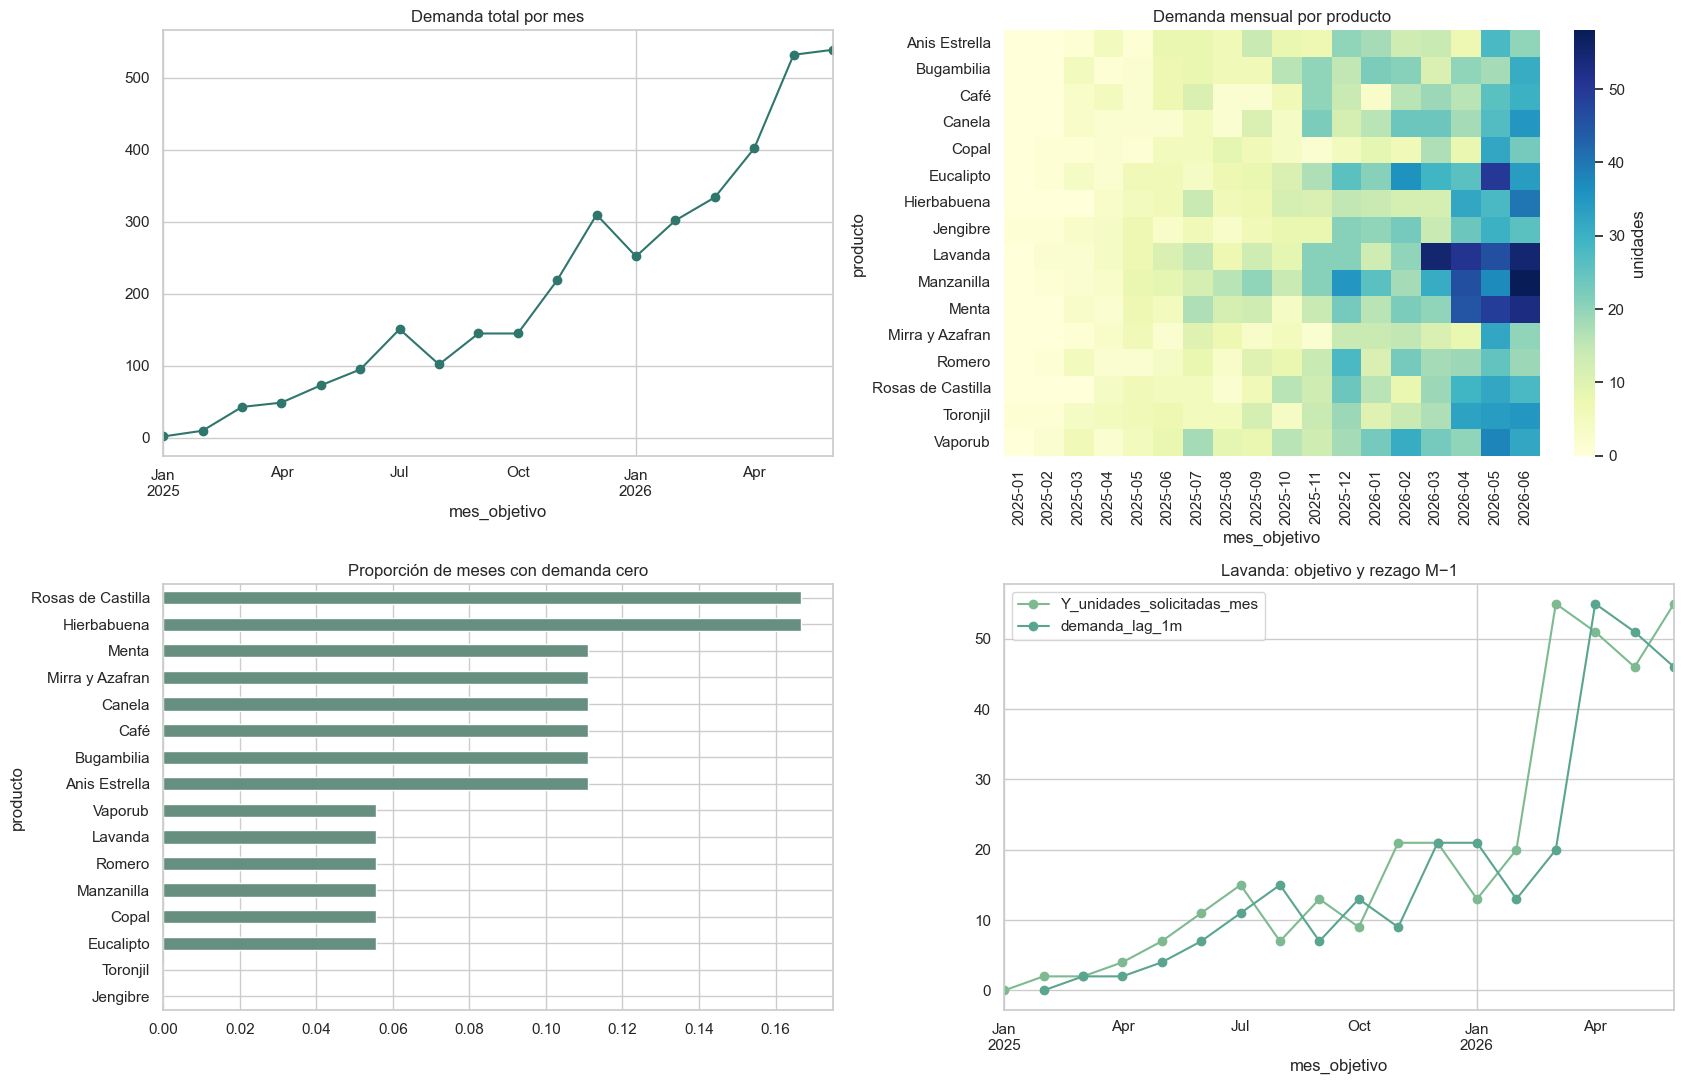

,valor
filas_base,288
filas_con_tres_rezagos,240
productos,16
meses,18


,unidades_solicitadas,meses_con_demanda
producto,,
Manzanilla,357,17
Lavanda,352,17
Menta,305,16
Eucalipto,288,17
Vaporub,272,17
Toronjil,226,18
Hierbabuena,217,15
Rosas de Castilla,213,15
Canela,209,16


In [5]:
target = 'Y_unidades_solicitadas_mes'
monthly_heatmap = demand.pivot_table(
    index='producto',
    columns=demand['mes_objetivo'].dt.to_period('M').astype(str),
    values=target,
    aggfunc='sum',
    fill_value=0,
)
monthly_total = demand.groupby('mes_objetivo')[target].sum()
zero_share = (
    demand.groupby('producto')[target]
    .apply(lambda values: values.eq(0).mean())
    .sort_values()
)
trainable = demand[['demanda_lag_1m', 'demanda_lag_2m', 'demanda_lag_3m']].notna().all(axis=1)
lavanda = demand.query("product_id == 'SYN-PROD-006'").set_index('mes_objetivo')

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
monthly_total.plot(ax=axes[0, 0], marker='o', color='#2f766d', title='Demanda total por mes')
sns.heatmap(monthly_heatmap, cmap='YlGnBu', ax=axes[0, 1], cbar_kws={'label': 'unidades'})
axes[0, 1].set_title('Demanda mensual por producto')
zero_share.plot.barh(ax=axes[1, 0], color='#668f80', title='Proporción de meses con demanda cero')
lavanda[[target, 'demanda_lag_1m']].plot(ax=axes[1, 1], marker='o', title='Lavanda: objetivo y rezago M−1')
plt.tight_layout()
plt.show()

display(pd.Series({
    'filas_base': len(demand),
    'filas_con_tres_rezagos': int(trainable.sum()),
    'productos': demand['product_id'].nunique(),
    'meses': demand['mes_objetivo'].nunique(),
}, name='valor').to_frame())

demand.groupby('producto').agg(
    unidades_solicitadas=(target, 'sum'),
    meses_con_demanda=(target, lambda values: values.gt(0).sum()),
).sort_values('unidades_solicitadas', ascending=False).head(10)

## 5. Dataset de segmentación

RFM utiliza recencia, frecuencia y monto. El diagnóstico K-Means extendido transforma las variables con `log1p`, escala y compara varios valores de `k`. No existe una etiqueta de segmento dentro del CSV.

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.3886,253.2555,0.9780
1,3,0.3601,225.3546,1.0031
2,4,0.3399,222.2943,0.9304
3,5,0.3381,226.6425,0.9604
4,6,0.3294,220.7172,0.9105
5,7,0.3356,225.9813,0.8976
6,8,0.3180,219.1663,0.9074


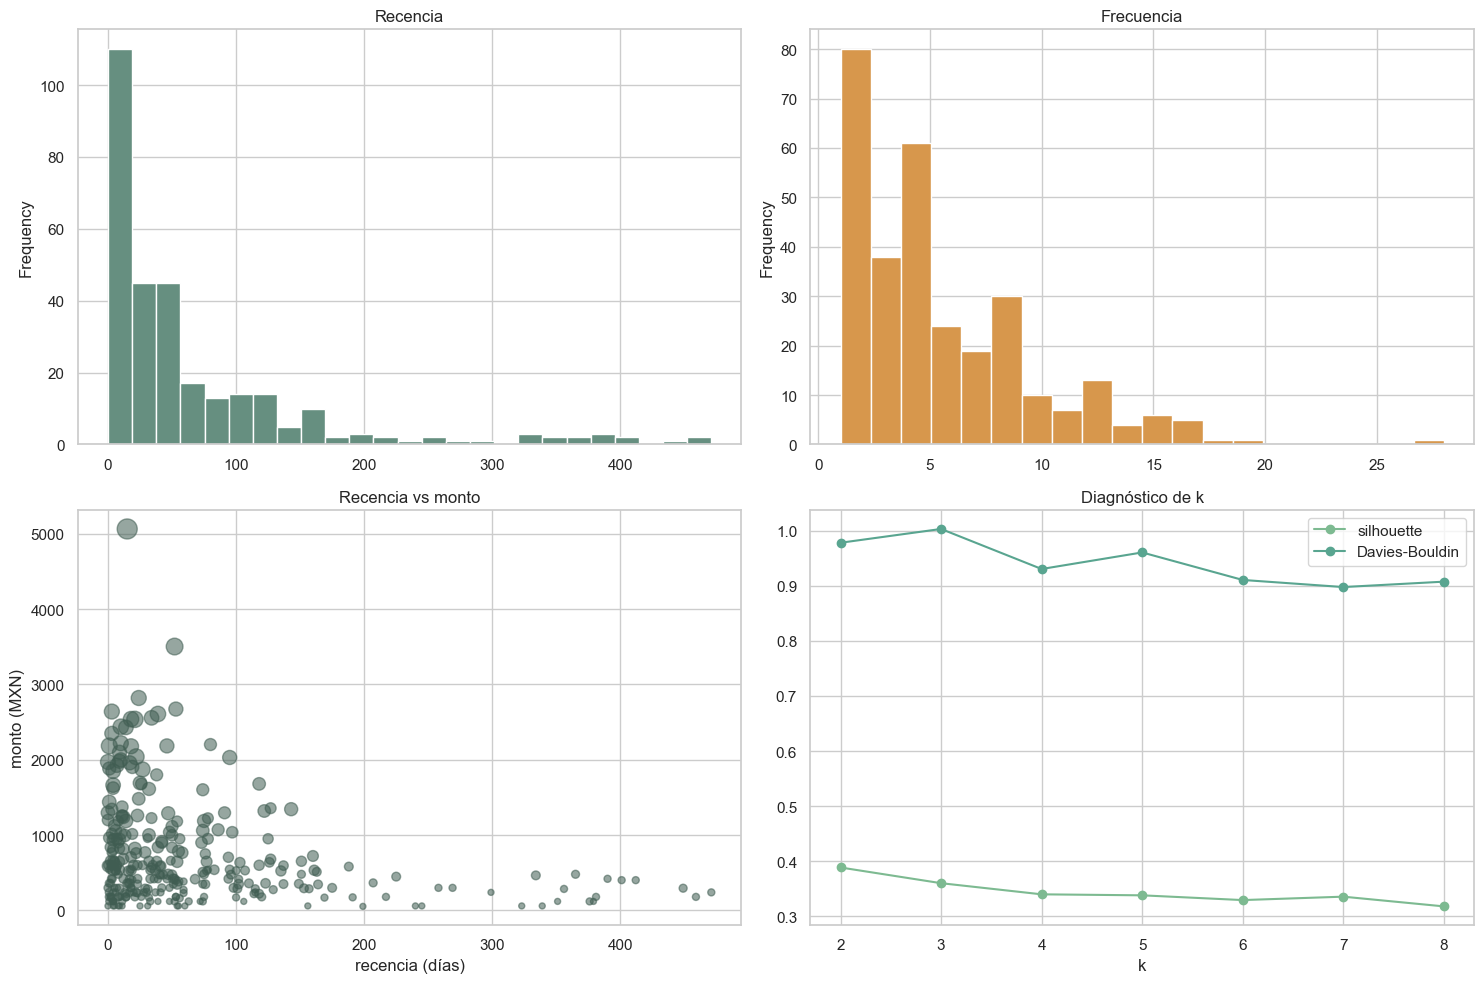

In [6]:
rfm_columns = ['recency_days', 'frequency_orders', 'monetary_value']
rfm_log = np.log1p(segmentation[rfm_columns])
rfm_scaled = StandardScaler().fit_transform(rfm_log)
diagnostics = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit_predict(rfm_scaled)
    diagnostics.append({
        'k': k,
        'silhouette': silhouette_score(rfm_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(rfm_scaled, labels),
        'davies_bouldin': davies_bouldin_score(rfm_scaled, labels),
    })
diagnostics = pd.DataFrame(diagnostics)
display(diagnostics.round(4))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
segmentation['recency_days'].plot.hist(bins=25, ax=axes[0, 0], color='#668f80', title='Recencia')
segmentation['frequency_orders'].plot.hist(bins=20, ax=axes[0, 1], color='#d7974c', title='Frecuencia')
axes[1, 0].scatter(segmentation['recency_days'], segmentation['monetary_value'], s=segmentation['frequency_orders'] * 7 + 12, alpha=0.55, color='#405d52')
axes[1, 0].set(title='Recencia vs monto', xlabel='recencia (días)', ylabel='monto (MXN)')
axes[1, 1].plot(diagnostics['k'], diagnostics['silhouette'], marker='o', label='silhouette')
axes[1, 1].plot(diagnostics['k'], diagnostics['davies_bouldin'], marker='o', label='Davies-Bouldin')
axes[1, 1].set(title='Diagnóstico de k', xlabel='k')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

## 6. Puerta final de calidad

El criterio profesional es cero errores críticos. Una calificación promedio alta nunca puede ocultar una reseña sin compra, un `order_id` futuro, un rezago mal calculado o información posterior a la fecha de corte.

In [7]:
quality_report = pd.read_csv(EXPORT_DIR / 'quality-report.csv', encoding='utf-8-sig')
quality_summary = json.loads((EXPORT_DIR / 'quality-summary.json').read_text(encoding='utf-8'))
display(quality_report.groupby(['dataset', 'severity', 'passed']).size().rename('checks').to_frame())
display(pd.Series(quality_summary, name='resultado'))
failed_errors = quality_report.query("severity == 'ERROR' and passed == False")
assert failed_errors.empty, failed_errors[['dataset', 'check', 'observed', 'expected']]
print('APROBADO: los tres datasets cumplen todos los controles críticos.')

checks
dataset       severity passed        
cruzado       ERROR    True         4
demanda       ERROR    True        24
              WARNING  True         1
recomendacion ERROR    True        17
              WARNING  True         4
segmentacion  ERROR    True        15
              WARNING  True         1

approved                                                        True
checks                                                            66
passed                                                            66
failed_errors                                                      0
failed_warnings                                                    0
row_counts         {'recommendation': 22274, 'demand': 288, 'segm...
Name: resultado, dtype: object

APROBADO: los tres datasets cumplen todos los controles críticos.


## Limitación académica

Estos datos permiten demostrar preparación, entrenamiento, evaluación e integración. Las métricas obtenidas describen el escenario sintético y no deben presentarse como evidencia de rendimiento futuro sobre clientes reales.